In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mirajdeepbhandari/polynomial-regression/Ice_cream selling data.csv


In [27]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [28]:
df = pd.read_csv("/kaggle/input/datasets/mirajdeepbhandari/polynomial-regression/Ice_cream selling data.csv")

In [29]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [30]:
df.shape

(49, 2)

In [31]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['temperature_(°c)', 'ice_cream_sales_(units)'], dtype='object')

In [32]:
df.isnull().sum()

temperature_(°c)           0
ice_cream_sales_(units)    0
dtype: int64

In [33]:
import seaborn as sns

<Axes: xlabel='temperature_(°c)', ylabel='ice_cream_sales_(units)'>

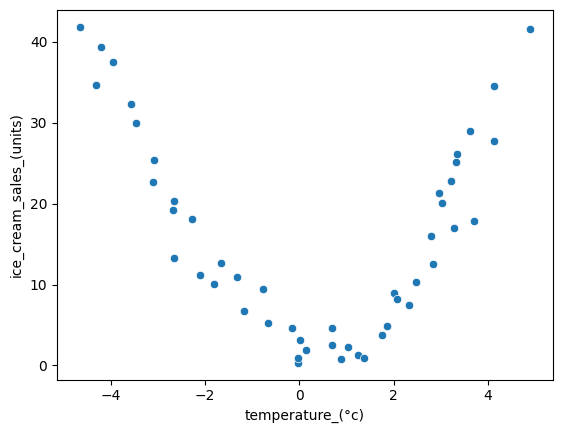

In [11]:
sns.scatterplot(x = "temperature_(°c)" , y = "ice_cream_sales_(units)" , data = df)

In [38]:
X = df.drop("ice_cream_sales_(units)", axis = 1)
y = df["ice_cream_sales_(units)"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 42)

In [48]:
# APPLYING SIMPLE LINEAR REGRESSION
slr = LinearRegression()
model_1 = slr.fit(X_train, y_train)

In [50]:
y_predict = model_1.predict(X_test)

In [55]:
print(f"MSE : {mean_squared_error(y_test, y_predict)}")
print(f"MAE : {mean_absolute_error(y_test, y_predict)}")
print(f"RMSE : {np.sqrt(mean_absolute_error(y_test, y_predict))}")
print(f"R2_score : {r2_score(y_test, y_predict)}")


MSE : 131.08025454550747
MAE : 10.52298046610357
RMSE : 3.243914374040038
R2_score : 0.013527080157335392


In [56]:
# applying polynomial regression
from sklearn.preprocessing import PolynomialFeatures
pf = PolynomialFeatures(degree=2)

In [78]:
x1 = pf.fit_transform(X)

In [74]:
x1_train, x1_test, y_train, y_test = train_test_split(x1,y, test_size = 0.3, random_state = 42)

In [75]:
model = slr.fit(x1_train, y_train)

In [76]:
y_pred = model.predict(x1_test)

In [77]:
print(f"MSE : {mean_squared_error(y_test, y_pred)}")
print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE : {np.sqrt(mean_absolute_error(y_test, y_pred))}")
print(f"R2_score : {r2_score(y_test, y_pred)}")


MSE : 13.36027498142077
MAE : 3.1143498510757346
RMSE : 1.7647520650436237
R2_score : 0.8994543494249359


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


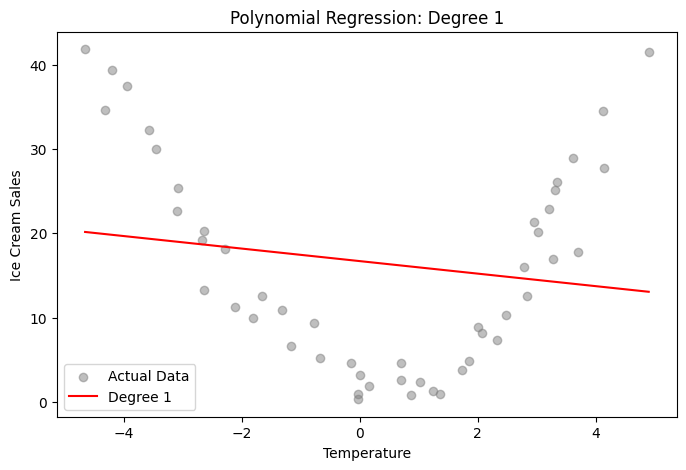

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


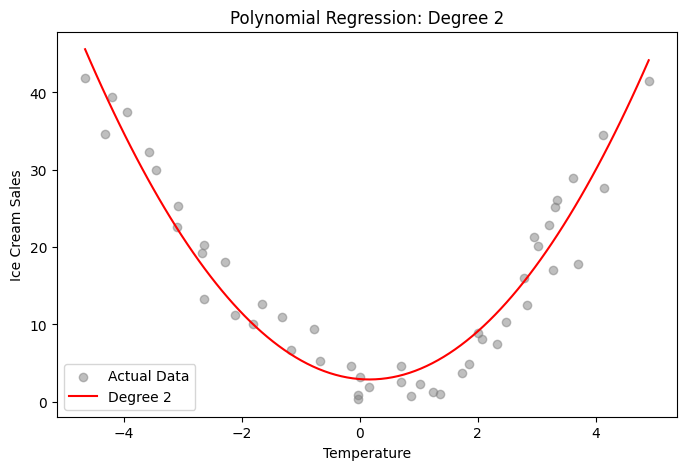

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


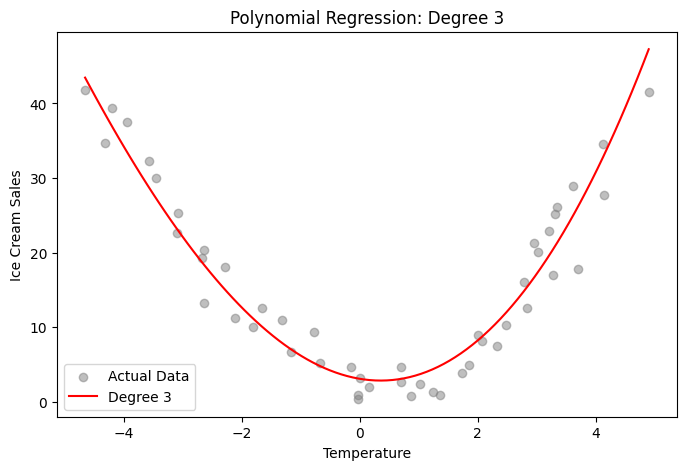

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


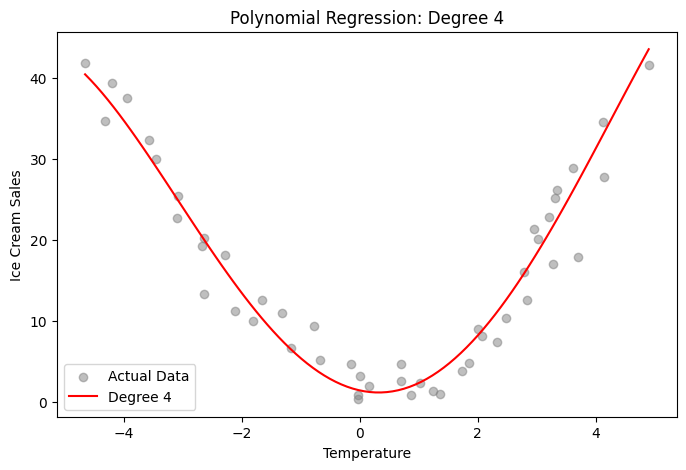

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


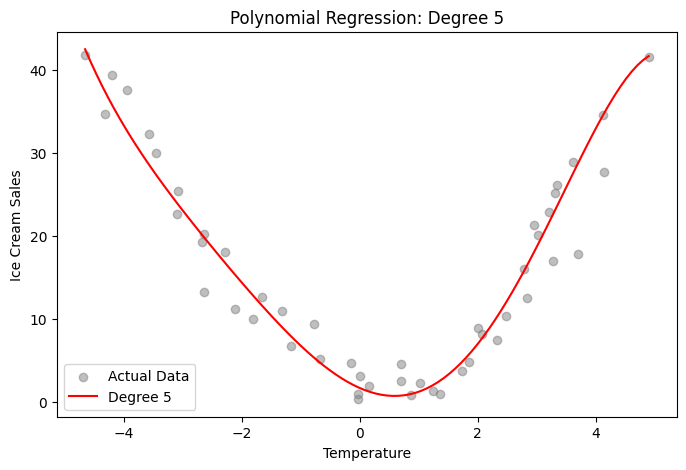

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


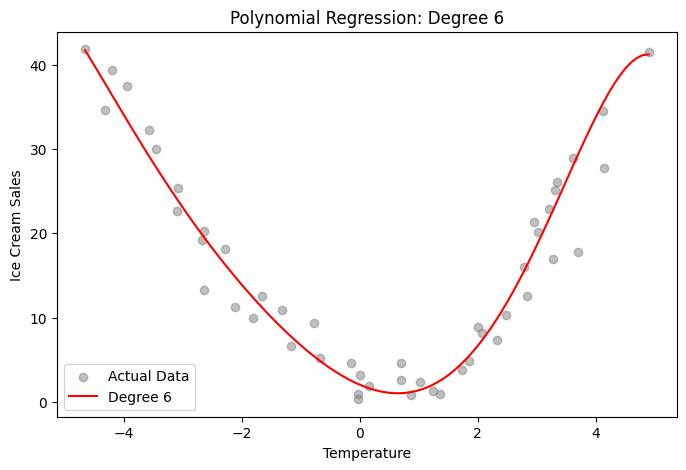

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


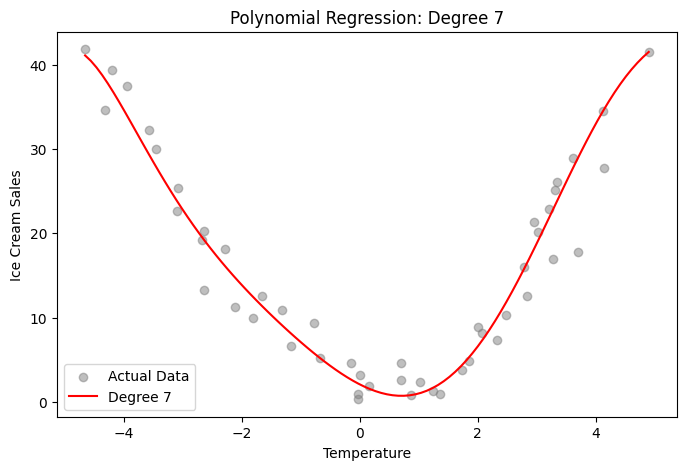

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


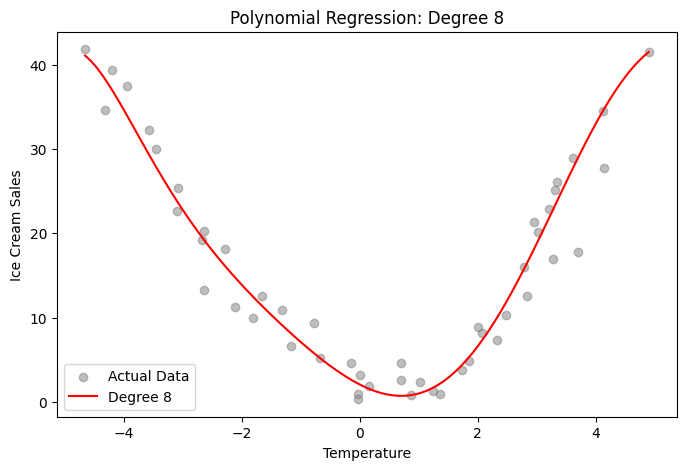

In [84]:
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

for i in range(1, 9):
    pf_3 = PolynomialFeatures(degree=i)
    x_poly = pf_3.fit_transform(X)
    
    x3_train, x3_test, y3_train, y3_test = train_test_split(x_poly, y, test_size=0.3, random_state=42)
    slr.fit(x3_train, y3_train)
    
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, label='Actual Data', color='gray', alpha=0.5)
    
    y_range_pred = slr.predict(pf_3.transform(X_range))
    plt.plot(X_range, y_range_pred, color="red", label=f"Degree {i}")
    
    plt.title(f"Polynomial Regression: Degree {i}")
    plt.xlabel("Temperature")
    plt.ylabel("Ice Cream Sales")
    plt.legend()
    plt.show()
    